In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("Food_Delivery_Time_Prediction.csv")

df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

,Distance,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,11.498050,5.250000,3.738500,3.686500,70.494950,1046.488700,46.616650
std,6.841755,2.745027,0.703021,0.697063,29.830694,548.568922,29.361706
min,0.520000,1.000000,2.500000,2.600000,15.230000,122.300000,1.240000
25%,6.090000,3.000000,3.200000,3.100000,46.997500,553.270000,21.602500
50%,10.265000,5.000000,3.800000,3.700000,72.775000,1035.950000,47.530000
75%,16.497500,8.000000,4.300000,4.300000,96.650000,1543.125000,70.245000
max,24.900000,10.000000,5.000000,5.000000,119.670000,1997.420000,99.740000


In [4]:
df.isnull().sum()

Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64

In [6]:
df.ffill(inplace=True)

In [7]:
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [8]:
print(df.columns)

Index(['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Distance',
       'Weather_Conditions', 'Traffic_Conditions',
       'Delivery_Person_Experience', 'Order_Priority', 'Order_Time',
       'Vehicle_Type', 'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time',
       'Order_Cost', 'Tip_Amount'],
      dtype='object')


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = [
    'Customer_Location',
    'Restaurant_Location',
    'Weather_Conditions',
    'Traffic_Conditions',
    'Order_Priority',
    'Vehicle_Type'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [10]:
import numpy as np

df['Delivery_Status'] = np.where(df['Delivery_Time'] <= 30, 0, 1)

In [11]:
X = df.drop(['Order_ID','Delivery_Time','Delivery_Status'], axis=1)

y = df['Delivery_Status']

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Order_Time'] = le.fit_transform(df['Order_Time'])

In [14]:
df.dtypes

Order_ID                       object
Customer_Location               int32
Restaurant_Location             int32
Distance                      float64
Weather_Conditions              int32
Traffic_Conditions              int32
Delivery_Person_Experience      int64
Order_Priority                  int32
Order_Time                      int32
Vehicle_Type                    int32
Restaurant_Rating             float64
Customer_Rating               float64
Delivery_Time                 float64
Order_Cost                    float64
Tip_Amount                    float64
Delivery_Status                 int32
dtype: object

In [15]:
X = df.drop(['Order_ID','Delivery_Time','Delivery_Status'], axis=1)

y = df['Delivery_Status']

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

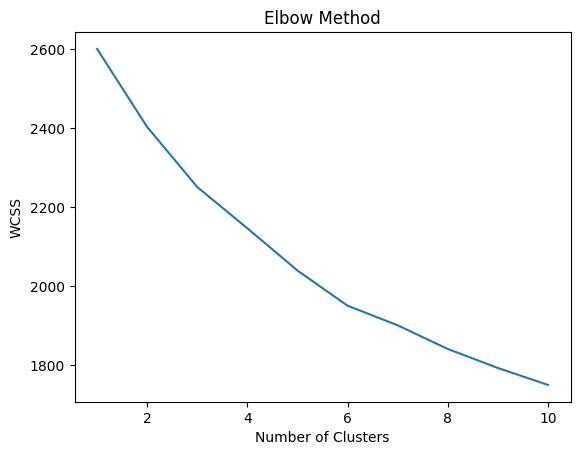

In [19]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

import matplotlib.pyplot as plt

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

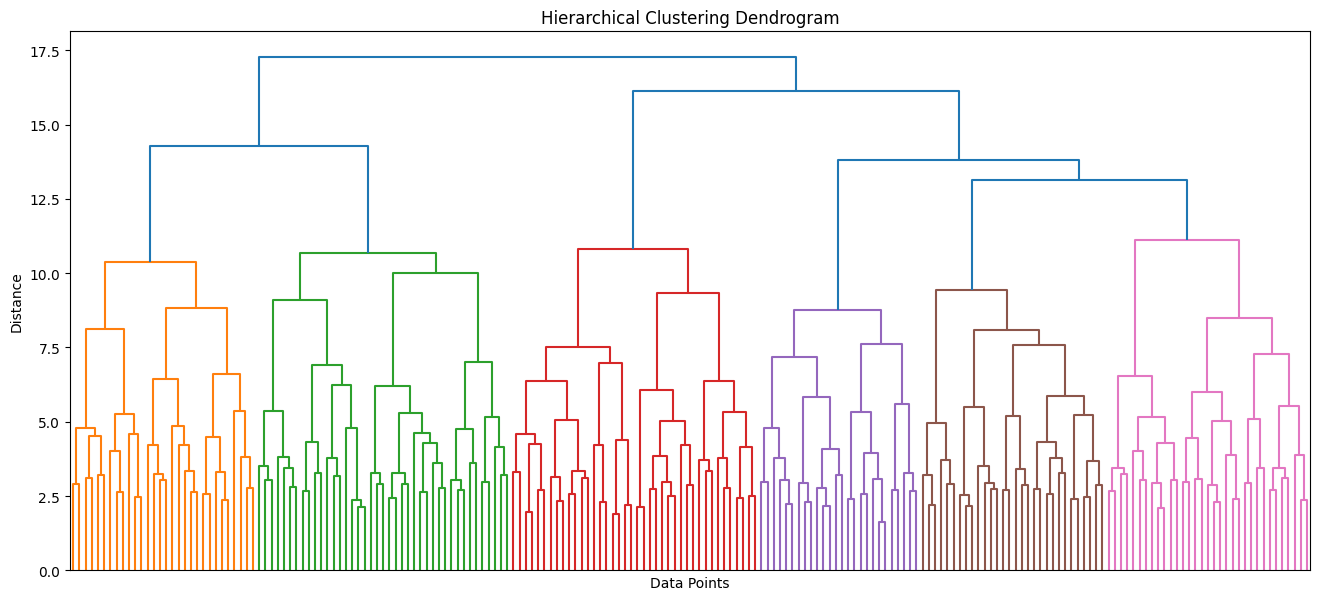

In [22]:
plt.figure(figsize=(16,7))

sch.dendrogram(
    sch.linkage(X_scaled, method='ward'),
    no_labels=True
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

In [23]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3)

y_hc = hc.fit_predict(X_scaled)

df['HC_Cluster'] = y_hc

In [24]:
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Delivery_Status,Cluster,HC_Cluster
0,ORD0001,98,10,1.57,1,2,4,2,0,2,4.1,3.0,26.22,1321.10,81.54,0,0,1
1,ORD0002,73,50,21.32,0,2,8,1,3,2,4.5,4.2,62.61,152.21,29.02,1,1,2
2,ORD0003,79,163,6.95,2,2,9,0,3,1,3.3,3.4,48.43,1644.38,64.17,1,2,2
3,ORD0004,160,107,13.79,0,1,2,2,1,1,3.2,3.7,111.63,541.25,79.23,1,0,0
4,ORD0005,65,71,6.72,1,0,6,1,3,1,3.5,2.8,32.38,619.81,2.34,1,1,1


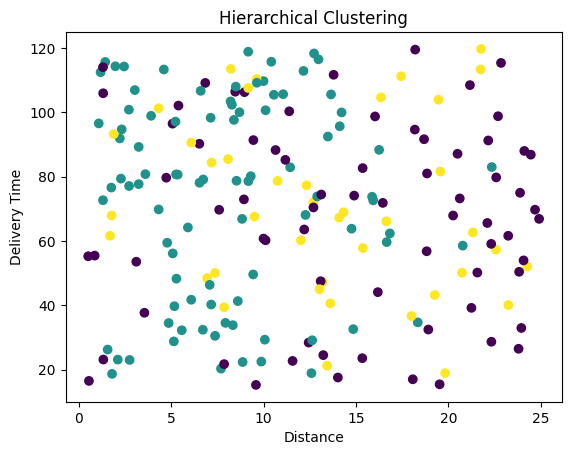

In [25]:
import matplotlib.pyplot as plt

plt.scatter(df['Distance'], df['Delivery_Time'], c=df['HC_Cluster'])

plt.title("Hierarchical Clustering")
plt.xlabel("Distance")
plt.ylabel("Delivery Time")

plt.show()

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [27]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [28]:
model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
4/4 [==============================] - 2s 141ms/step - loss: 0.7631 - accuracy: 0.3828 - val_loss: 0.7562 - val_accuracy: 0.3125
Epoch 2/20
4/4 [==============================] - 0s 22ms/step - loss: 0.7079 - accuracy: 0.4531 - val_loss: 0.7120 - val_accuracy: 0.4688
Epoch 3/20
4/4 [==============================] - 0s 18ms/step - loss: 0.6562 - accuracy: 0.6016 - val_loss: 0.6729 - val_accuracy: 0.6250
Epoch 4/20
4/4 [==============================] - 0s 17ms/step - loss: 0.6100 - accuracy: 0.7031 - val_loss: 0.6373 - val_accuracy: 0.7188
Epoch 5/20
4/4 [==============================] - 0s 16ms/step - loss: 0.5737 - accuracy: 0.7812 - val_loss: 0.6045 - val_accuracy: 0.7500
Epoch 6/20
4/4 [==============================] - 0s 32ms/step - loss: 0.5371 - accuracy: 0.8281 - val_loss: 0.5762 - val_accuracy: 0.7500
Epoch 7/20
4/4 [==============================] - 0s 17ms/step - loss: 0.5054 - accuracy: 0.8594 - val_loss: 0.5505 - val_accuracy: 0.8438
Epoch 8/20
4/4 [==========

In [29]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5)

2/2 [==============================] - 0s 7ms/step


In [31]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.85
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.85      1.00      0.92        34

    accuracy                           0.85        40
   macro avg       0.42      0.50      0.46        40
weighted avg       0.72      0.85      0.78        40



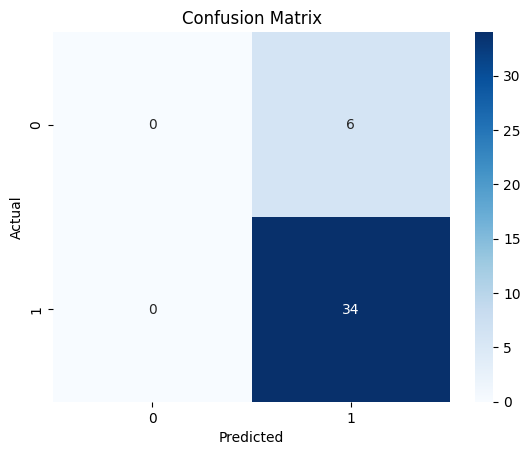

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

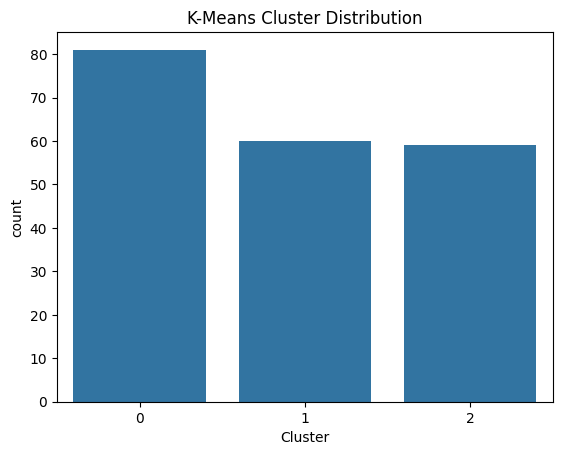

In [33]:
sns.countplot(x='Cluster', data=df)

plt.title("K-Means Cluster Distribution")

plt.show()

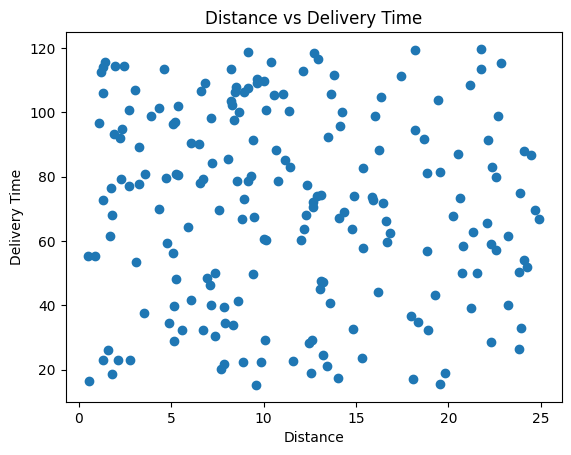

In [34]:
plt.scatter(df['Distance'], df['Delivery_Time'])

plt.title("Distance vs Delivery Time")
plt.xlabel("Distance")
plt.ylabel("Delivery Time")

plt.show()

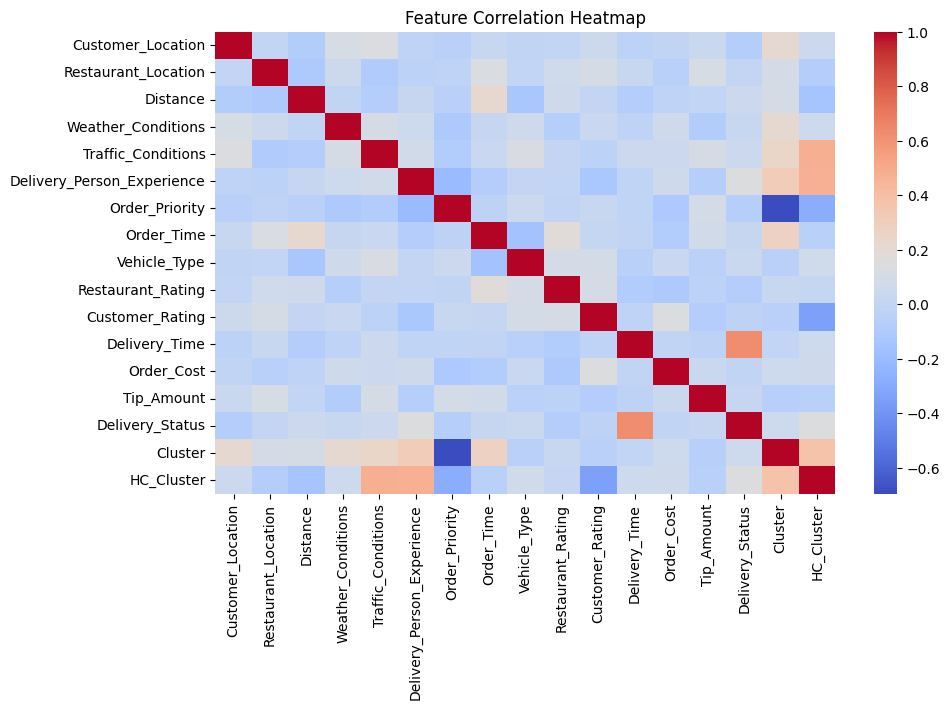

In [36]:
plt.figure(figsize=(10,6))

sns.heatmap(df.select_dtypes(include=['number']).corr(), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

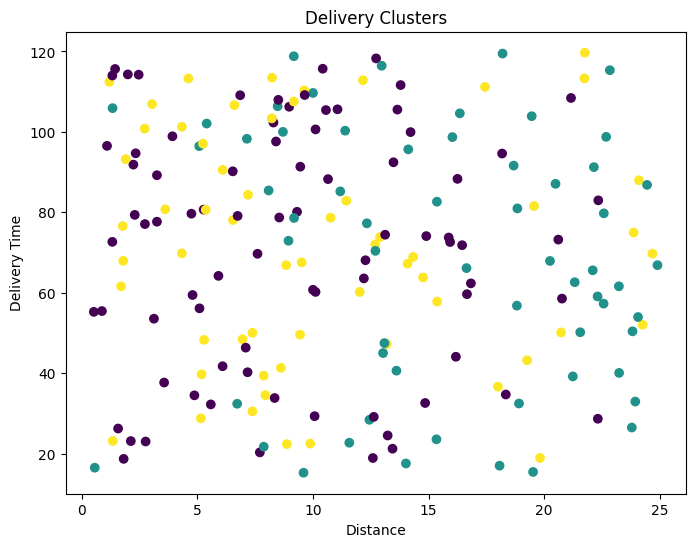

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(df['Distance'], df['Delivery_Time'], c=df['Cluster'], cmap='viridis')

plt.title("Delivery Clusters")
plt.xlabel("Distance")
plt.ylabel("Delivery Time")

plt.show()

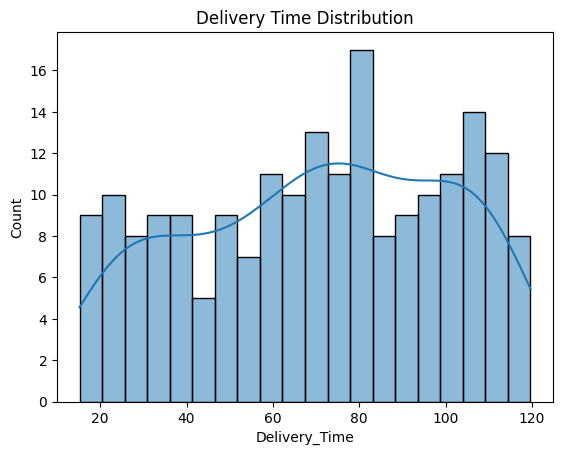

In [38]:
sns.histplot(df['Delivery_Time'], bins=20, kde=True)

plt.title("Delivery Time Distribution")

plt.show()

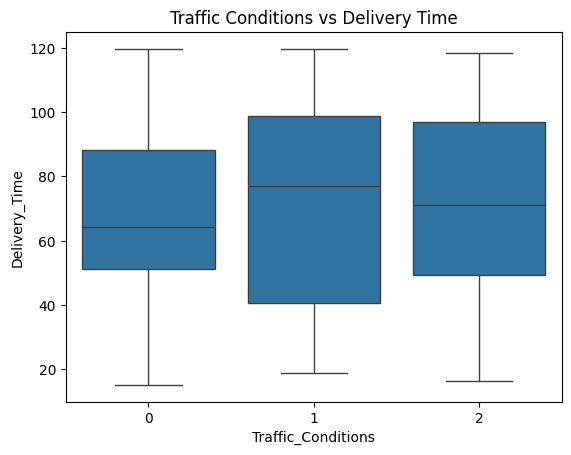

In [39]:
sns.boxplot(x=df['Traffic_Conditions'], y=df['Delivery_Time'])

plt.title("Traffic Conditions vs Delivery Time")

plt.show()

# Key Insights

Traffic conditions significantly affect delivery time.

Longer delivery distances result in higher delivery time.

Clustering reveals patterns in delivery behavior under different weather and traffic conditions.

Neural network models can effectively classify deliveries as Fast or Delayed.

These insights can help food delivery companies optimize routes and improve efficiency.